# [Tutorial](https://github.com/yashizhang/esm/tree/main/cookbook/tutorials): Which Layer Should You Use? A Layer Sweep for Enzyme Function Classification

ESMC is a transformer model, which means protein representations are computed in stages: each transformer layer refines the model's understanding, building from low-level residue chemistry in the early layers to high-level functional context in the later ones. **The final layer is not always the best layer for your task.**

This tutorial demonstrates how to systematically evaluate every layer of ESMC (Layer sweep) by asking a simple question: given a protein's sequence, can ESMC's embeddings tell us what broad type of chemical reaction that protein catalyzes?

We use Enzyme Commission (EC) numbers as labels—a standardized system that classifies enzymes by reaction type in a four-level hierarchy. In this tutorial, we focus on third-level EC prefixes (e.g., 3.1.3), which group enzymes by closely related reaction types while keeping the problem tractable.

You can think of this as sorting proteins into buckets: 
- kinases (transfer phosphate groups)
- phosphatases (remove phosphate groups)
- oxidoreductases (transfer electrons)
- lyases (break or form bonds without hydrolysis). 

These classes are chemically distinct, but the proteins within each class can look very different in sequence and structure, making this a meaningful test of what the model has learned.

We then ask: which layer’s embeddings give the best classification performance with a simple (linear) model?

## Learning goals

After completing this tutorial, you will be able to:

- Extract embeddings from all ESMC layers and average across the sequence to obtain one vector per protein per layer
- Build a layer sweep: train a linear probe on each layer and compare performance
- Interpret the performance curve to identify which layer is best for your task
- Apply this workflow to your own classification or regression problem

## Background: Why do layers differ?

Protein language models learn a hierarchy of representations as information flows through their layers:

- Early layers tend to capture local sequence features such as amino acid identity and short-range chemical context.
- Middle layers often encode higher-order structural or functional patterns, including motifs and evolutionary constraints.
- The last layer is directly optimized for the model's training objective (e.g., masked token prediction) and may become more specialized to that objective.
- Late layers are often the best for contact prediction [(Vig et al. 2020)](https://arxiv.org/abs/2006.15222).

In practice, this means **the most useful layer depends on your task**. For example, enzyme function classification often peaks in intermediate layers, while other tasks (e.g., stability prediction) may favor different depths. The most reliable way to determine this is empirical: measure performance across layers.

If, however, you don't have enough data to work with, we recommend the following guidelines:

- If you are predicting a functional property (thermostability, solubility, etc), we recommend using the **second to last layer** `[-2]`
- If you are looking for high-level functional similarity (EC number, GO term, homology, etc), we recommend using a **layer ~3/4** of the way through the network.

## What this notebook does

We use a pre-built dataset of ~600 reviewed (SwissProt) enzymes spanning 4 EC classes. We embed them with ESMC and fit a logistic regression probe on each layer's mean-pooled representations. Performance is evaluated with 5-fold cross-validation, reporting MCC across layers to determine which layer works the best for the task. 

**Note on scope:** This tutorial uses the ESMC 600M model. The results are best interpreted as a comparison across layers rather than a rigorous benchmark. We find that the 6B model is best for a variety of protein representation learning tasks. 


## 1. Install and import dependencies

Plus set up some utilities. 

In [ ]:
# If you are working in colab, uncomment these lines to install dependencies
# !pip install esm@git+https://github.com/yashizhang/esm.git@main

In [ ]:
from getpass import getpass

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import matthews_corrcoef
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm

from esm.sdk import batch_executor, esmc_client
from esm.sdk.api import ESMProtein, ESMProteinError, LogitsConfig

## 2. Set up Biohub client. 
First, we need to set up the Biohub client. Generate an API key on the [Biohub platform](https://biohub.ai) and add it to your account. This API key manages your access to credits and tokens, and the term API key/token is often used interchangeably within documentation.

Please note that your API key is like a password for your account and you should take care to protect it. For this reason it is recommended to frequently create a new API key and delete old, unused ones. It is also recommended to paste the API key directly into an environment variable or use a utility like `getpass` as shown in the example below so keys are not accidentally shared or checked into code repositories.


We use **ESMC 600M** here. It has 36 transformer layers, making the sweep fast enough to run interactively. The same workflow applies to the 300M and 6B models .

In [ ]:
token = getpass("Biohub API token: ")

model_name = "esmc-600m-2024-12"
forge_client = esmc_client(model=model_name, url="https://biohub.ai", token=token)

## 3. Fetch the enzyme dataset from UniProt

We use a pre-built dataset of ~600 reviewed (SwissProt) enzymes spanning 4 EC classes, downloaded from Google Drive. This dataset was generated by querying the UniProt REST API for manually curated entries with high-confidence EC annotations.

In [3]:
# Download the pre-built EC dataset from Google Drive
!wget --no-check-certificate "https://drive.google.com/uc?export=download&id=1zi-vnJOfvZs2uv3PmSxeiW7EFtK05tvV" -O ec_layer_sweep_dataset.csv

df = pd.read_csv("ec_layer_sweep_dataset.csv")

print("\nClass counts:")
print(df["ec_prefix"].value_counts().sort_index())
print(f"\nFinal dataset: {len(df)} proteins")
df.head()

--2026-05-12 17:20:03--  https://drive.google.com/uc?export=download&id=1zi-vnJOfvZs2uv3PmSxeiW7EFtK05tvV
Resolving drive.google.com (drive.google.com)... 2607:f8b0:4005:815::200e, 142.251.215.78
Connecting to drive.google.com (drive.google.com)|2607:f8b0:4005:815::200e|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1zi-vnJOfvZs2uv3PmSxeiW7EFtK05tvV&export=download [following]
--2026-05-12 17:20:03--  https://drive.usercontent.google.com/download?id=1zi-vnJOfvZs2uv3PmSxeiW7EFtK05tvV&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 2607:f8b0:4005:806::2001, 142.251.218.65
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|2607:f8b0:4005:806::2001|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 392654 (383K) [application/octet-stream]
Saving to: ‘ec_layer_sweep_dataset.csv’

ec_layer_sweep_data 100%[=================

,accession,entry_name,protein_name,organism,ec,length,sequence,ec_prefix
0,O15297,PPM1D_HUMAN,Protein phosphatase 1D (EC 3.1.3.16) (Protein ...,Homo sapiens (Human),3.1.3.16,605,MAGLYSLGVSVFSDQGGRKYMEDVTQIVVEPEPTAEEKPSPRRSLS...,3.1.3
1,O60729,CC14B_HUMAN,Dual specificity protein phosphatase CDC14B (E...,Homo sapiens (Human),3.1.3.16; 3.1.3.48,498,MKRKSERRSSWAAAPPCSRRCSSTSPGVKKIRSSTQQDPRRRDPQD...,3.1.3
2,O75319,DUS11_HUMAN,RNA/RNP complex-1-interacting phosphatase (EC ...,Homo sapiens (Human),3.1.3.-,330,MSQWHHPRSGWGRRRDFSGRSSAKKKGGNHIPERWKDYLPVGQRMP...,3.1.3
3,O75365,TP4A3_HUMAN,Protein tyrosine phosphatase type IVA 3 (EC 3....,Homo sapiens (Human),3.1.3.48,173,MARMNRPAPVEVSYKHMRFLITHNPTNATLSTFIEDLKKYGATTVV...,3.1.3
4,P09467,F16P1_HUMAN,"Fructose-1,6-bisphosphatase 1 (FBPase 1) (EC 3...",Homo sapiens (Human),3.1.3.11,338,MADQAPFDTDVNTLTRFVMEEGRKARGTGELTQLLNSLCTAVKAIS...,3.1.3


**EC classes:** We use four third-level EC prefixes representing chemically distinct reaction types. Using the third level (e.g., `3.1.3`) gives us a manageable number of classes while still posing a meaningful discrimination challenge — these are mechanistically distinct but all involve nucleotide chemistry or redox reactions, so they are not trivially separable.

| EC prefix | Reaction type |
|-----------|---------------|
| 3.1.3 | Phosphoric monoester hydrolases (phosphatases) |
| 2.7.1 | Phosphotransferases with alcohol acceptor (kinases) |
| 1.1.1 | Oxidoreductases acting on CH–OH with NAD+/NADP+ |
| 4.2.1 | Hydro-lyases |


## 5. Embed proteins with ESMC

For each protein, we extract representations from every layer of ESMC. Each layer produces a vector for every residue in the sequence, so we average across residues to obtain a single vector per protein per layer.

This results in an embedding array of shape (n_proteins, n_layers, hidden_dim) — for example, (593, 37, 1152) for ESMC 600M.

In [4]:
# Using return_mean_hidden_states=True is more memory efficient
# than returning all hidden states and pooling locally.
EMBEDDING_CONFIG = LogitsConfig(
    sequence=True,
    return_mean_hidden_states=True,  # returns mean-pooled hidden states (n_layers, hidden_dim)
)


def embed_sequence(model, sequence):
    protein = ESMProtein(sequence=sequence)
    protein_tensor = model.encode(protein)
    output = model.logits(protein_tensor, EMBEDDING_CONFIG)
    # We want to propagate errors to the batch executor.
    if isinstance(output, ESMProteinError):
        raise output
    return output.mean_hidden_state.squeeze().float().numpy()

In [5]:
sequences = df["sequence"].tolist()
labels = df["ec_prefix"].tolist()

print(f"Embedding {len(sequences):,} proteins (this may take several minutes)...")
with batch_executor() as executor:
    outputs = executor.execute_batch(
        user_func=embed_sequence, model=forge_client, sequence=sequences
    )

valid = [isinstance(o, np.ndarray) for o in outputs]
sequences = [s for s, v in zip(sequences, valid) if v]
labels = [l for l, v in zip(labels, valid) if v]
all_embeddings = np.stack([o for o, v in zip(outputs, valid) if v], axis=0)

N_LAYERS = all_embeddings.shape[1]
HIDDEN_DIM = all_embeddings.shape[2]
print(
    f"\nEmbedding matrix shape: {all_embeddings.shape}  → (n_proteins, n_layers, hidden_dim)"
)

Embedding 593 proteins (this may take several minutes)...


Processing  100%|████████████████████████| 593/593 [Elapsed: 01:12 | Remaining: 00:00] , Success=593 Fail=0 Retry=216


Embedding matrix shape: (593, 37, 1152)  → (n_proteins, n_layers, hidden_dim)


## 6. Layer sweep: train a linear probe on each layer

For each layer we:
1. Extract the mean-pooled embedding for that layer across all proteins
2. Train a **logistic regression classifier** with 5-fold cross-validation 
   - If performance is high at layer $\ell$, it indicates that EC class information is already encoded in a form that can be extracted with a simple linear model—without requiring more complex nonlinear decoding.
3. Record **MCC [(Matthews Correlation Coefficient)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.matthews_corrcoef.html):** Ranges from −1 (complete disagreement) to +1 (perfect prediction). It accounts for class imbalance and is generally preferred over accuracy for multi-class problems.


In [6]:
N_SPLITS = 5  # number of cross-validation folds
RANDOM_STATE = 44

classes = sorted(pd.unique(labels))
y = np.array([classes.index(l) for l in labels])

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

mcc_scores = np.zeros((N_LAYERS, N_SPLITS))

print(f"Running {N_SPLITS}-fold CV across {N_LAYERS} layers...")

for layer_idx in tqdm(range(N_LAYERS), desc="Layer sweep"):
    X_layer = all_embeddings[:, layer_idx, :]  # (n_proteins, hidden_dim)

    pipe = Pipeline(
        [
            ("scaler", StandardScaler()),
            (
                "clf",
                LogisticRegression(
                    max_iter=1000, random_state=RANDOM_STATE, solver="lbfgs", C=0.1
                ),
            ),
        ]
    )

    for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X_layer, y)):
        X_train, X_test = X_layer[train_idx], X_layer[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)

        mcc_scores[layer_idx, fold_idx] = matthews_corrcoef(y_test, y_pred)


mcc_mean, mcc_std = mcc_scores.mean(axis=1), mcc_scores.std(axis=1)

best_mcc_layer = int(mcc_mean.argmax())
last_layer = N_LAYERS - 1

print(
    f"\nBest layer by MCC:   layer {best_mcc_layer + 1}  (MCC = {mcc_mean[best_mcc_layer]:.3f})"
)
print(
    f"Last layer:          layer {last_layer + 1}       (MCC = {mcc_mean[last_layer]:.3f})"
)

Running 5-fold CV across 37 layers...


/var/folders/nk/0860l6gs5vnfnn5jdnzbz9qw0000gq/T/ipykernel_74612/1798675473.py:4: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  classes = sorted(pd.unique(labels))


Layer sweep:   0%|          | 0/37 [00:00<?, ?it/s]


Best layer by MCC:   layer 25  (MCC = 0.935)
Last layer:          layer 37       (MCC = 0.843)


## 7. Visualize the layer sweep

Next we will visualize how classification performance varies across transformer layers. This plot shows how well a simple linear model can extract enzyme function from each layer’s embeddings, using MCC as an evaluation metric. By examining performance as a function of depth, we can identify where in the network function-relevant information is most accessible.

In [7]:
def plot_layer_sweep(
    layers,
    mcc_mean,
    mcc_std,
    best_mcc_layer,
    last_layer,
    save_path="ec_layer_sweep.png",
):
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(layers, mcc_mean, "o-", linewidth=2, label="MCC", color="steelblue")
    ax.fill_between(
        layers,
        mcc_mean - mcc_std,
        mcc_mean + mcc_std,
        alpha=0.2,
        color="steelblue",
        label="±1 std",
    )
    ax.axvline(
        best_mcc_layer + 1,
        color="steelblue",
        linestyle=":",
        linewidth=1.5,
        label=f"Best MCC layer = {best_mcc_layer + 1}",
    )
    ax.axvline(
        last_layer + 1,
        color="gray",
        linestyle=":",
        linewidth=1.5,
        label=f"Last layer = {last_layer + 1}",
    )
    ax.set_xlabel("Transformer layer", fontsize=12)
    ax.set_ylabel("CV performance", fontsize=12)
    ax.set_title(
        "EC classification performance by ESMC layer\n"
        "(mean-pooled embeddings + logistic regression, 5-fold CV)",
        fontsize=13,
    )
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.set_xlim(0.5, last_layer + 1.5)
    ax.grid(axis="y", alpha=0.3)
    ax.legend(fontsize=10)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Figure saved to {save_path}")
    plt.show()

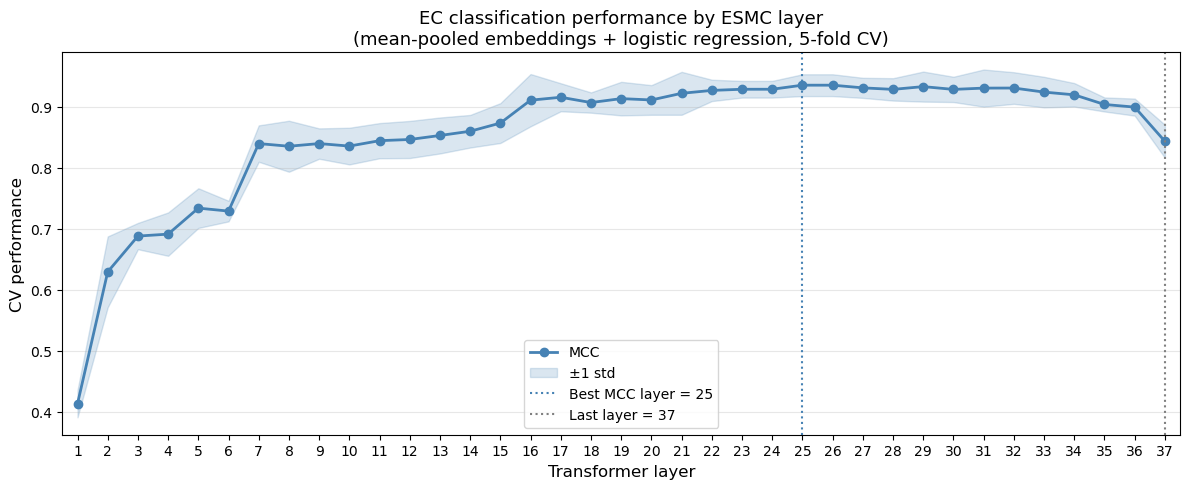

In [8]:
plot_layer_sweep(
    np.arange(1, N_LAYERS + 1),
    mcc_mean,
    mcc_std,
    best_mcc_layer,
    last_layer,
    save_path=None,
)

### Interpreting the performance curve

We see the EC number is captured well by middle layers of the model, which captures information about functional similarity. We also observe a drop in performance at the last layer. This may appear because the final layer is most specialized for the model's training objective (next-token/masked-token prediction) rather than higher level representation. 

### What do the embeddings look like?

So far, we’ve evaluated each layer quantitatively using a linear probe. To build intuition, we can visualize the representations with PCA projections of the embeddings, to see how proteins cluster by EC class in a low-dimensional space. We compare the best layer to the last layer. 

In [9]:
def plot_pca_projections(
    all_embeddings, labels, classes, best_mcc_layer, last_layer, random_state=42
):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    projections = []
    for layer_idx in [best_mcc_layer, last_layer]:
        X = all_embeddings[:, layer_idx, :]
        X_2d = PCA(n_components=2, random_state=random_state).fit_transform(
            StandardScaler().fit_transform(X)
        )
        projections.append(X_2d)
    all_coords = np.concatenate(projections, axis=0)
    lim = np.abs(all_coords).max() * 1.05
    titles = [
        f"Best layer (layer {best_mcc_layer + 1})",
        f"Last layer (layer {last_layer + 1})",
    ]
    for ax, X_2d, title in zip(axes, projections, titles):
        for label, color in zip(
            classes, plt.cm.Set1(np.linspace(0, 0.8, len(classes)))
        ):
            mask = np.array(labels) == label
            ax.scatter(
                X_2d[mask, 0],
                X_2d[mask, 1],
                label=f"EC {label}",
                color=color,
                s=20,
                alpha=0.6,
            )
        ax.set_title(title)
        ax.set_xlabel("PC 1")
        ax.set_ylabel("PC 2")
        ax.set_xlim(-lim, lim)
        ax.set_ylim(-lim, lim)
        ax.legend(fontsize=8)
    plt.suptitle("PCA of mean-pooled ESMC embeddings by EC class", y=1.02)
    plt.tight_layout()
    plt.show()

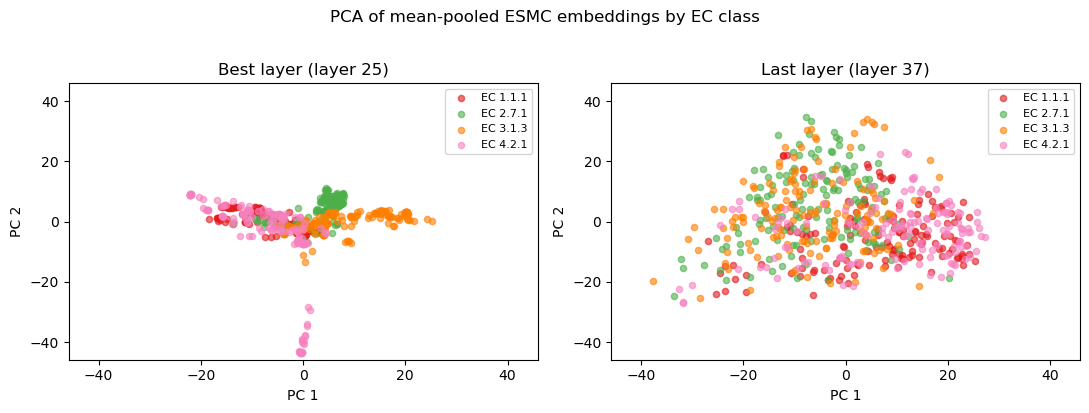

In [10]:
plot_pca_projections(
    all_embeddings,
    labels,
    classes,
    best_mcc_layer,
    last_layer,
    random_state=RANDOM_STATE,
)

At the best-performing layer, proteins roughly cluster by EC class, though there is still some overlap between classes. In contrast, the final layer shows substantial mixing between classes, suggesting that this separability is partially lost.

## 8. Summary table and takeaways

Print a summary of the best layers and the performance gap between the best and last layer.

In [11]:
summary = pd.DataFrame(
    {
        "Layer": np.arange(1, N_LAYERS + 1),
        "MCC mean": mcc_mean.round(3),
        "MCC std": mcc_std.round(3),
    }
)

# Show top 5 layers
top5 = summary.nlargest(5, "MCC mean")[["Layer", "MCC mean", "MCC std"]]
print("\nTop 5 layers by MCC:")
print(top5.to_string(index=False))


Top 5 layers by MCC:
 Layer  MCC mean  MCC std
    25     0.935    0.018
    26     0.935    0.018
    29     0.933    0.025
    27     0.931    0.016
    31     0.931    0.030


## Next steps

**Apply this to your own task.**  
- The layer sweep approach can generalize to any labeled protein problem. You can replace the dataset and labels in Section 4 with your own task (e.g., stability, binding affinity, localization), then run the same workflow.  
- The *optimal layer does not necessarily transfer across tasks*. Different biological properties are encoded at different depths, so the best-performing layer for function classification may differ from that for structure prediction or regression tasks.  
- In some cases, you may also need to adjust the probe (e.g., regression instead of classification) or evaluation metric to match your task. The key idea is to treat layer choice as a hyperparameter and determine it empirically.


**Try different probes.**  
- We use logistic regression as a simple linear probe, but other models can extract different signals from the same embeddings. For example:

    - **Ridge regression** for continuous outputs (e.g., thermostability)
    - **SVMs or tree-based models** for more complex decision boundaries  

- If a more expressive model improves performance, it may indicate that useful information is present but not linearly separable.


**Explore other ESMC models.**  
- In this tutorial, we use the **600M model** for speed. Other models (e.g., 6B) follow the same workflow but may have richer representations for your task.


**For more investigation on the latent space of ESMC, see the preprint!**